# BL3 Proton Backscattering Analysis with Python

This notebook analyzes a million-event Geant4 simulation of proton backscattering from the BL3 segmented silicon detector. It follows the initial proton coordinates through the rerun, selects events that deposit energy in the silicon, and measures how many final proton positions fall outside the detector's 50 mm outer radius.

The analysis complements the detector-position and pixel-rate study in `detector_analysis.ipynb`. Some loading, coordinate transformation, detector geometry, and plotting code is intentionally repeated so this notebook can also be read on its own.


## 1. Simulation method and analysis plan

The original Geant4 simulation was modified to record the state of protons when they backscattered from the detector. Those recorded positions and momenta were then used as the initial conditions for a new simulation run. In this simplified backscattering model, the rerun samples the possible energy and direction of a proton leaving the detector surface and follows the proton to determine whether it returns to the active detector area.

For this notebook, I:

1. load the initial and final coordinates, momentum components, and silicon energy deposition from the ROOT file;
2. select events with nonzero silicon energy deposition (`SiEdep > 0`);
3. transform the global y coordinate into the detector-centered coordinate system;
4. compare the initial and final spatial distributions; and
5. count final positions outside the detector's 50 mm outer radius.


## 2. Imports and detector configuration

I use the same detector-centered coordinate convention and six ring boundaries as the main detector-analysis notebook.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import uproot

pd.set_option("display.precision", 4)

DATA_PATH = Path("data") / "backscattering_1M_20230714.root"
DETECTOR_Y_CENTER_MM = 121.0
DETECTOR_OUTER_RADIUS_MM = 50.0

# Detector-ring boundaries used in the main analysis
PIXEL_RING_EDGES_MM = np.array([0.0, 3.7, 9.1, 15.0, 24.0, 35.0, 50.0])


## 3. Load and validate the ROOT data

The ROOT file contains one million simulated events. I use the same `Event;5` tree selected in the original backscattering analysis.


In [2]:
branches = [
    "x0", "y0", "z0",
    "px0", "py0", "pz0", "pTot",
    "E0", "T0", "SiEdep",
    "xh", "yh", "zh",
]

with uproot.open(DATA_PATH) as root_file:
    tree = root_file["Event;5"]
    events = tree.arrays(branches, library="np")

load_summary = pd.DataFrame({
    "ROOT file": [DATA_PATH.name],
    "events": [len(events["x0"])],
    "tree": [tree.name],
})

load_summary


,ROOT file,events,tree
0,backscattering_1M_20230714.root,1000000,Event


## 4. Select detector hits and transform coordinates

I select events with nonzero silicon energy deposition. The same Boolean mask is applied to all final-coordinate arrays so the x, y, and z values continue to describe the same events.


In [15]:
deposited_mask = events["SiEdep"] > 0

initial = {
    "x": events["x0"],
    "y": events["y0"] - DETECTOR_Y_CENTER_MM,
    "z": events["z0"],
}

final_hits = {
    "x": events["xh"][deposited_mask],
    "y": events["yh"][deposited_mask] - DETECTOR_Y_CENTER_MM,
    "z": events["zh"][deposited_mask],
    "SiEdep": events["SiEdep"][deposited_mask],
}

selection_summary = pd.DataFrame({
    "events": [len(events["SiEdep"])],
    "SiEdep > 0": [int(deposited_mask.sum())],
    "fraction with SiEdep > 0": [deposited_mask.mean()],
})

selection_summary


,events,SiEdep > 0,fraction with SiEdep > 0
0,1000000,921380,0.9214


## 5. Silicon energy deposition

The energy-deposition distribution checks the response of the simulated silicon detector for the selected events.


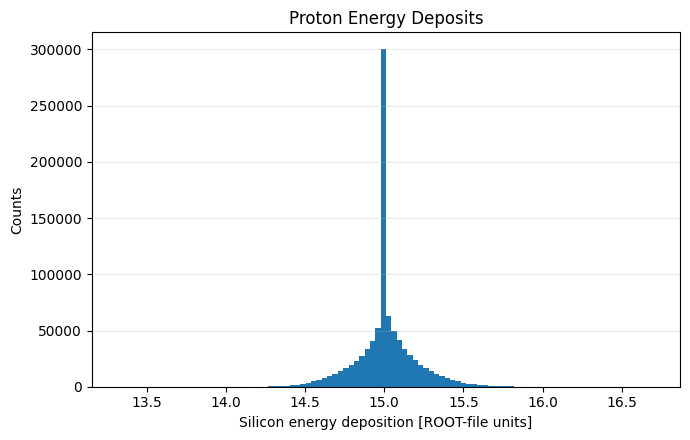

,mean,standard deviation
0,15.0101,0.1847


In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(final_hits["SiEdep"], bins=100)
ax.set_xlabel("Silicon energy deposition [ROOT-file units]")
ax.set_ylabel("Counts")
ax.set_title("Proton Energy Deposits")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
plt.show()

energy_summary = pd.DataFrame({
    "mean": [np.mean(final_hits["SiEdep"])],
    "standard deviation": [np.std(final_hits["SiEdep"])],
})

energy_summary


## 6. Initial and final spatial summaries

The initial coordinates describe the backscattered protons used to begin the rerun. The final coordinates describe the selected events after transport through the simulated apparatus.


In [5]:
def summarize_xy(label, coordinates):
    return {
        "sample": label,
        "events": len(coordinates["x"]),
        "x mean [mm]": np.mean(coordinates["x"]),
        "y mean [mm]": np.mean(coordinates["y"]),
        "x std [mm]": np.std(coordinates["x"]),
        "y std [mm]": np.std(coordinates["y"]),
    }


spatial_summary = pd.DataFrame([
    summarize_xy("Initial backscatter state", initial),
    summarize_xy("Final state with SiEdep > 0", final_hits),
]).set_index("sample")

spatial_summary


,events,x mean [mm],y mean [mm],x std [mm],y std [mm]
sample,,,,,
Initial backscatter state,1000000,3.0883,0.5062,13.1307,12.4584
Final state with SiEdep > 0,921380,2.2647,0.9689,14.2767,13.4664


## 7. Detector acceptance

A selected final hit is outside the modeled detector when its detector-centered radius is greater than 50 mm. The supplied nominal-position run contains **3 such events out of 1,000,000 simulated events**, corresponding to an observed fraction of $3\times10^{-6}$ per generated event.

This value describes the simplified rerun model. It should not be interpreted as a measured material backscattering probability without also including the physical probability for a proton to backscatter from the silicon in the first place.


In [6]:
final_radius_mm = np.hypot(final_hits["x"], final_hits["y"])
outside_detector = final_radius_mm > DETECTOR_OUTER_RADIUS_MM

acceptance_summary = pd.DataFrame({
    "quantity": [
        "Generated events",
        "Events with SiEdep > 0",
        "Selected final positions outside 50 mm",
        "Outside fraction per generated event",
    ],
    "value": [
        len(events["x0"]),
        int(deposited_mask.sum()),
        int(outside_detector.sum()),
        outside_detector.sum() / len(events["x0"]),
    ],
})

acceptance_summary


,quantity,value
0,Generated events,1.0000e+06
1,Events with SiEdep > 0,9.2138e+05
2,Selected final positions outside 50 mm,3.0000e+00
3,Outside fraction per generated event,3.0000e-06


## 8. Initial and final proton distributions

Both panels use the same coordinate range, binning, logarithmic count scale, and detector-ring overlays. This makes the change from the initial backscatter state to the final detected distribution directly visible.


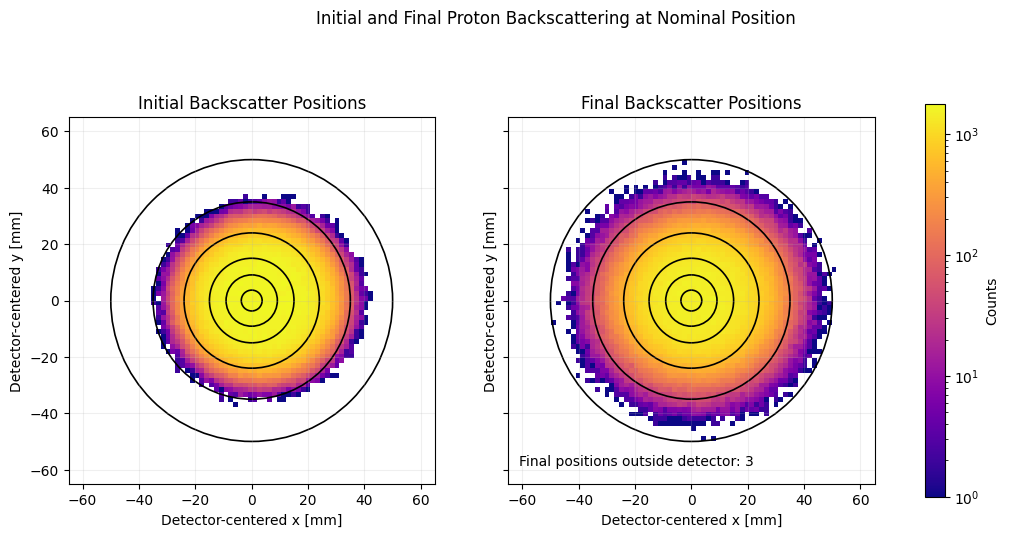

In [17]:
edges = np.linspace(-65, 65, 77)

initial_hist, _, _ = np.histogram2d(
    initial["x"], initial["y"], bins=(edges, edges)
)
final_hist, _, _ = np.histogram2d(
    final_hits["x"], final_hits["y"], bins=(edges, edges)
)

global_max = max(initial_hist.max(), final_hist.max())
norm = LogNorm(vmin=1, vmax=global_max)
extent = [edges[0], edges[-1], edges[0], edges[-1]]

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

image = axes[0].imshow(
    initial_hist.T,
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="plasma",
    norm=norm,
)
axes[1].imshow(
    final_hist.T,
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="plasma",
    norm=norm,
)

axes[0].set_title("Initial Backscatter Positions")
axes[1].set_title("Final Backscatter Positions")

for ax in axes:
    for radius in PIXEL_RING_EDGES_MM[1:]:
        ax.add_patch(plt.Circle(
            (0, 0), radius, fill=False, color="black", linewidth=1.2
        ))
    ax.set_xlabel("Detector-centered x [mm]")
    ax.set_ylabel("Detector-centered y [mm]")
    ax.grid(alpha=0.2)

axes[1].text(
    0.03,
    0.05,
    f"Final positions outside detector: {outside_detector.sum()}",
    transform=axes[1].transAxes,
)

fig.colorbar(image, ax=axes, label="Counts", shrink=0.85)
fig.suptitle("Initial and Final Proton Backscattering at Nominal Position")

Path("figures").mkdir(exist_ok=True)
fig.savefig(
    "figures/backscattering_initial_final_comparison.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## 9. Two- and three-dimensional trajectory views

Scatter plots provide a qualitative check of the simulated geometry. Plotting all one million events would obscure the structure and create an unnecessarily large figure, so I use a reproducible random sample for these diagnostic views.


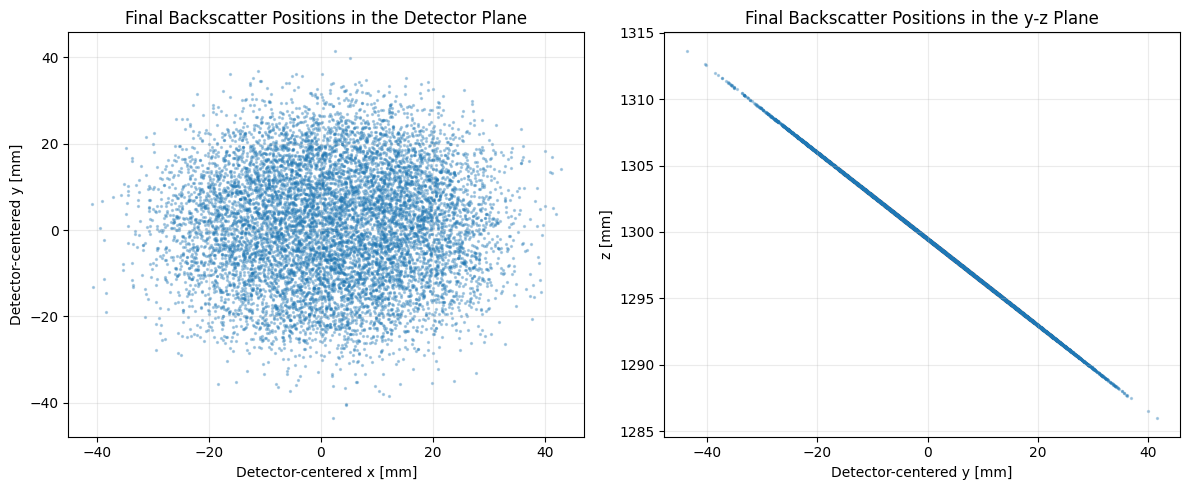

In [18]:
rng = np.random.default_rng(2023)
sample_size = min(10_000, len(final_hits["x"]))
sample_indices = rng.choice(len(final_hits["x"]), size=sample_size, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    final_hits["x"][sample_indices],
    final_hits["y"][sample_indices],
    s=2,
    alpha=0.3,
)
axes[0].set_xlabel("Detector-centered x [mm]")
axes[0].set_ylabel("Detector-centered y [mm]")
axes[0].set_title("Final Backscatter Positions in the Detector Plane")

axes[1].scatter(
    final_hits["y"][sample_indices],
    final_hits["z"][sample_indices],
    s=2,
    alpha=0.3,
)
axes[1].set_xlabel("Detector-centered y [mm]")
axes[1].set_ylabel("z [mm]")
axes[1].set_title("Final Backscatter Positions in the y-z Plane")

for ax in axes:
    ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()


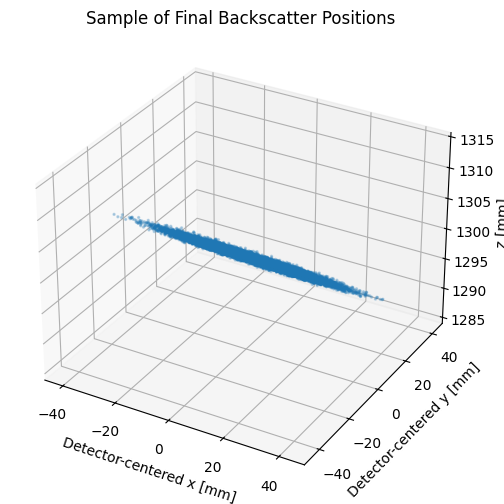

In [19]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    final_hits["x"][sample_indices],
    final_hits["y"][sample_indices],
    final_hits["z"][sample_indices],
    s=2,
    alpha=0.25,
)

ax.set_xlabel("Detector-centered x [mm]")
ax.set_ylabel("Detector-centered y [mm]")
ax.set_zlabel("z [mm]")
ax.set_title("Sample of Final Backscatter Positions")

plt.show()


## 10. Interpretation

The supplied million-event simulation produced three selected final positions outside the detector's 50 mm outer radius. The result indicates that loss beyond the detector edge was very small under the conditions of this simplified backscattering rerun.

This study is best interpreted as a transport and geometric-acceptance check. The simulation begins from proton states assigned at the detector surface and tests whether those protons return to the active detector area. A more complete detector-efficiency model would additionally use a physically motivated distribution of backscattered energies and directions and the probability that the initial silicon interaction produces a backscattered proton.
